In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [12]:
df = pd.read_csv('Global_Superstore.csv')

# Display the first few rows of the DataFrame.
print(df.head())

   Row ID                  Order ID  Order Date   Ship Date     Ship Mode  \
0   40098  CA-2014-AB10015140-41954  11/11/2014  11/13/2014   First Class   
1   26341    IN-2014-JR162107-41675    2/5/2014    2/7/2014  Second Class   
2   25330    IN-2014-CR127307-41929  10/17/2014  10/18/2014   First Class   
3   13524   ES-2014-KM1637548-41667   1/28/2014   1/30/2014   First Class   
4   47221   SG-2014-RH9495111-41948   11/5/2014   11/6/2014      Same Day   

    Customer ID     Customer Name      Segment  Postal Code           City  \
0  AB-100151402     Aaron Bergman     Consumer      73120.0  Oklahoma City   
1     JR-162107     Justin Ritter    Corporate          NaN     Wollongong   
2     CR-127307      Craig Reiter     Consumer          NaN       Brisbane   
3    KM-1637548  Katherine Murray  Home Office          NaN         Berlin   
4    RH-9495111       Rick Hansen     Consumer          NaN          Dakar   

   ...   Product ID    Category Sub-Category  \
0  ...  TEC-PH-5816 

In [5]:
# Check the shape of the DataFrame (number of rows and columns)
print("Shape of the DataFrame:", df.shape)

# Display information about the DataFrame (data types, non-null values, memory usage)
print("\nDataFrame Info:")
df.info()

# Generate descriptive statistics for numerical columns
print("\nDescriptive Statistics for numerical columns:")
print(df.describe())

# Generate descriptive statistics for all columns, including non-numerical ones
print("\nDescriptive Statistics for all columns:")
print(df.describe(include='all'))

Shape of the DataFrame: (1000, 24)

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          1000 non-null   int64  
 1   Order ID        1000 non-null   object 
 2   Order Date      1000 non-null   object 
 3   Ship Date       1000 non-null   object 
 4   Ship Mode       1000 non-null   object 
 5   Customer ID     1000 non-null   object 
 6   Customer Name   1000 non-null   object 
 7   Segment         1000 non-null   object 
 8   Postal Code     194 non-null    float64
 9   City            1000 non-null   object 
 10  State           1000 non-null   object 
 11  Country         1000 non-null   object 
 12  Region          1000 non-null   object 
 13  Market          1000 non-null   object 
 14  Product ID      1000 non-null   object 
 15  Category        1000 non-null   object 
 16  Sub-Category    1000 non-nu

In [6]:
# Check for missing values across all columns
print("Missing values before cleaning:")
print(df.isnull().sum())

# Convert 'Order Date' and 'Ship Date' to datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%m/%d/%Y')

# Verify the data types after conversion
print("\nDataFrame Info after date conversion:")
df.info()

print("\nMissing values after cleaning (should only be 'Postal Code' if not dropped):")
print(df.isnull().sum())

Missing values before cleaning:
Row ID              0
Order ID            0
Order Date          0
Ship Date           0
Ship Mode           0
Customer ID         0
Customer Name       0
Segment             0
Postal Code       806
City                0
State               0
Country             0
Region              0
Market              0
Product ID          0
Category            0
Sub-Category        0
Product Name        0
Sales               0
Quantity            0
Discount            0
Profit              0
Shipping Cost       0
Order Priority      0
dtype: int64

DataFrame Info after date conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          1000 non-null   int64         
 1   Order ID        1000 non-null   object        
 2   Order Date      1000 non-null   datetime64[ns]
 3   Ship Date       1

In [7]:
# Calculate total sales and profit
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
print(f"Total Sales: ${total_sales:,.2f}")
print(f"Total Profit: ${total_profit:,.2f}")
print(f"Overall Profit Margin: {((total_profit / total_sales) * 100):.2f}%")

# Identify top-selling products (by sum of Sales)
top_selling_products = df.groupby('Product Name')['Sales'].sum().nlargest(10)
print("\nTop 10 Selling Products (by Sales):")
print(top_selling_products)

# Identify top profitable products (by sum of Profit)
top_profitable_products = df.groupby('Product Name')['Profit'].sum().nlargest(10)
print("\nTop 10 Most Profitable Products:")
print(top_profitable_products)

# Analyze sales by region (by sum of Sales)
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print("\nSales by Region:")
print(sales_by_region)

# Analyze profit by region (by sum of Profit)
profit_by_region = df.groupby('Region')['Profit'].sum().sort_values(ascending=False)
print("\nProfit by Region:")
print(profit_by_region)

# Examine the relationship between sales and profit
sales_profit_correlation = df['Sales'].corr(df['Profit'])
print(f"\nCorrelation between Sales and Profit: {sales_profit_correlation:.2f}")

# Examine correlation between Discount and Profit
discount_profit_correlation = df['Discount'].corr(df['Profit'])
print(f"Correlation between Discount and Profit: {discount_profit_correlation:.2f}")

Total Sales: $1,710,971.47
Total Profit: $288,920.44
Overall Profit Margin: 16.89%

Top 10 Selling Products (by Sales):
Product Name
Motorola Smart Phone, Full Size                             48542.52
Apple Smart Phone, Full Size                                42303.44
Cisco Smart Phone, Full Size                                41325.20
Nokia Smart Phone, Full Size                                27661.97
Samsung Smart Phone, Cordless                               25438.59
Hoover Stove, Red                                           23477.81
Motorola Smart Phone, with Caller ID                        23239.44
Harbour Creations Executive Leather Armchair, Adjustable    22145.80
Cisco Smart Phone, with Caller ID                           22047.89
Cisco Smart Phone, Cordless                                 21954.87
Name: Sales, dtype: float64

Top 10 Most Profitable Products:
Product Name
Motorola Smart Phone, Full Size                             13088.28
Hoover Stove, Red                

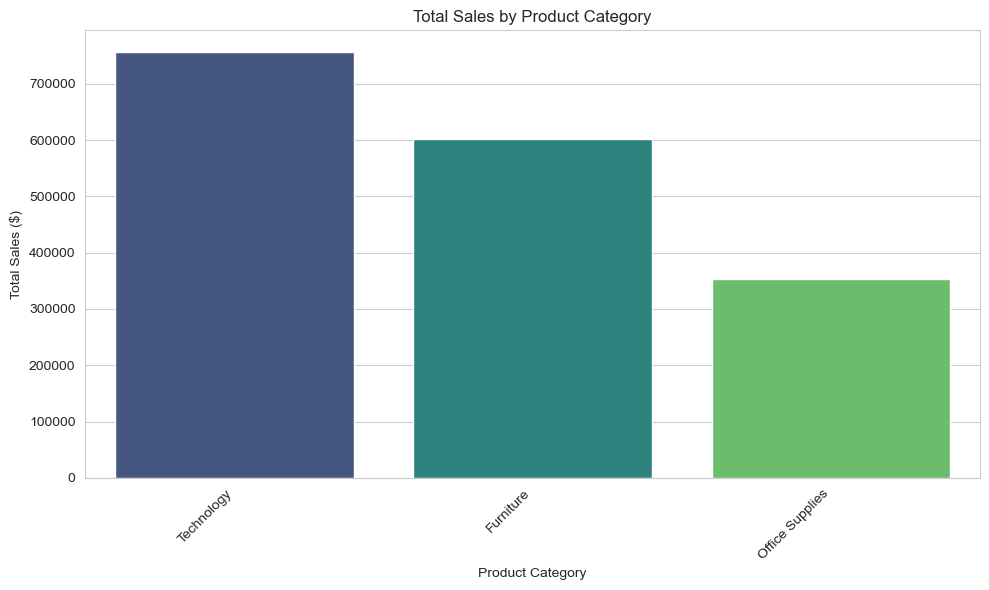

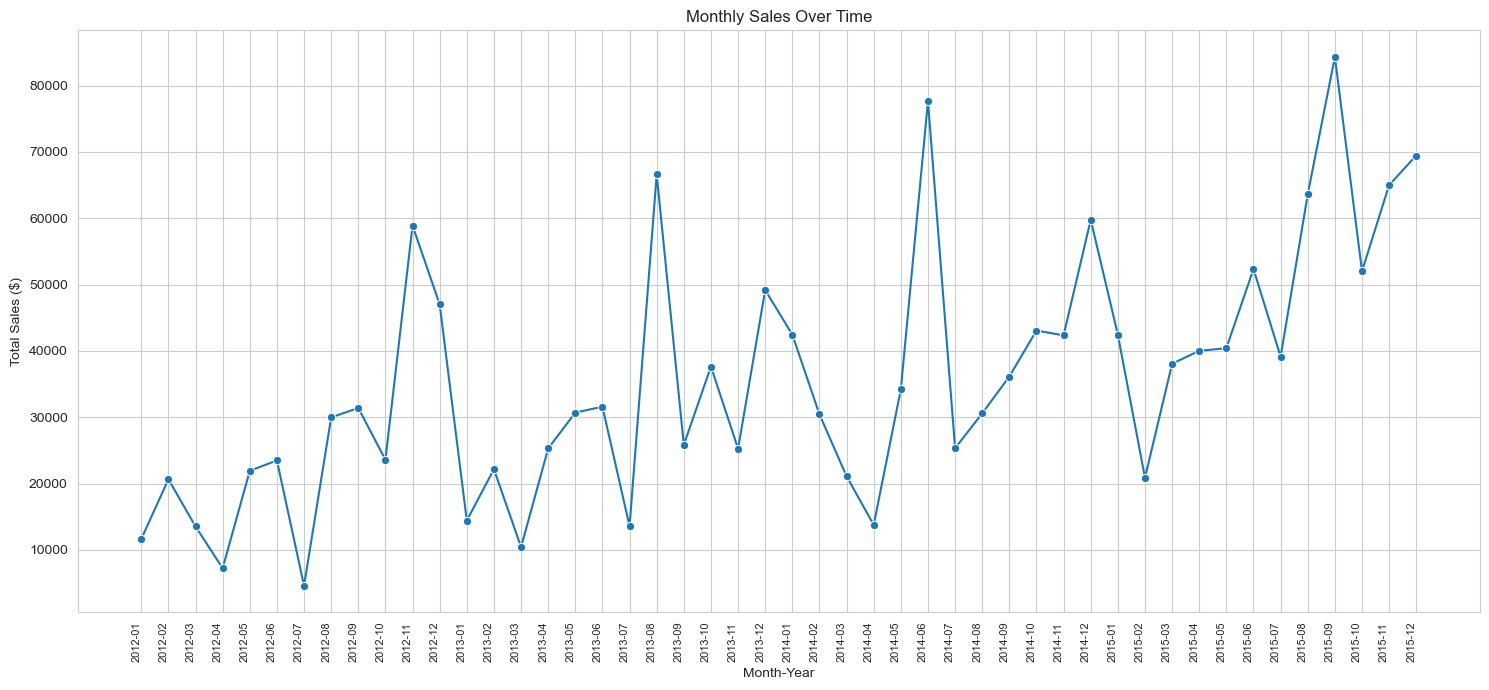

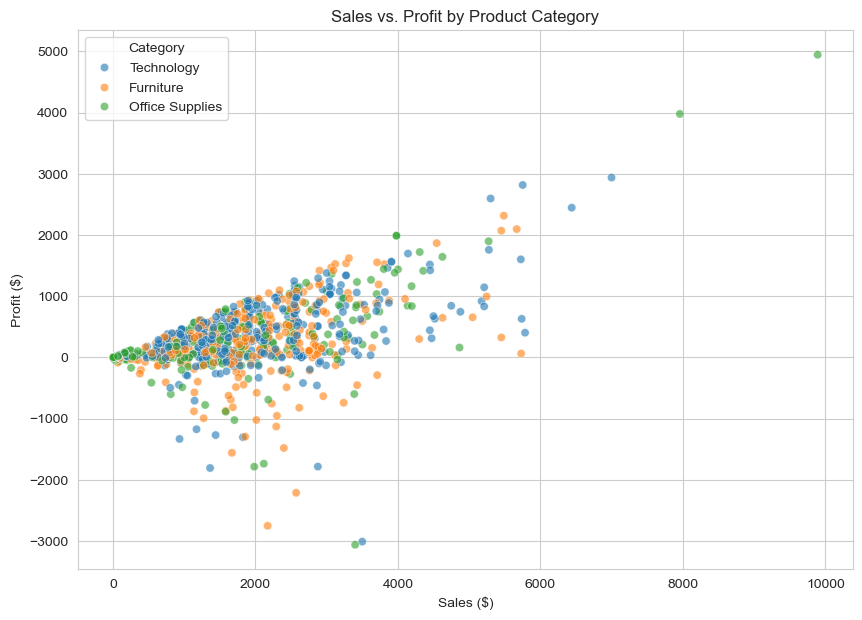

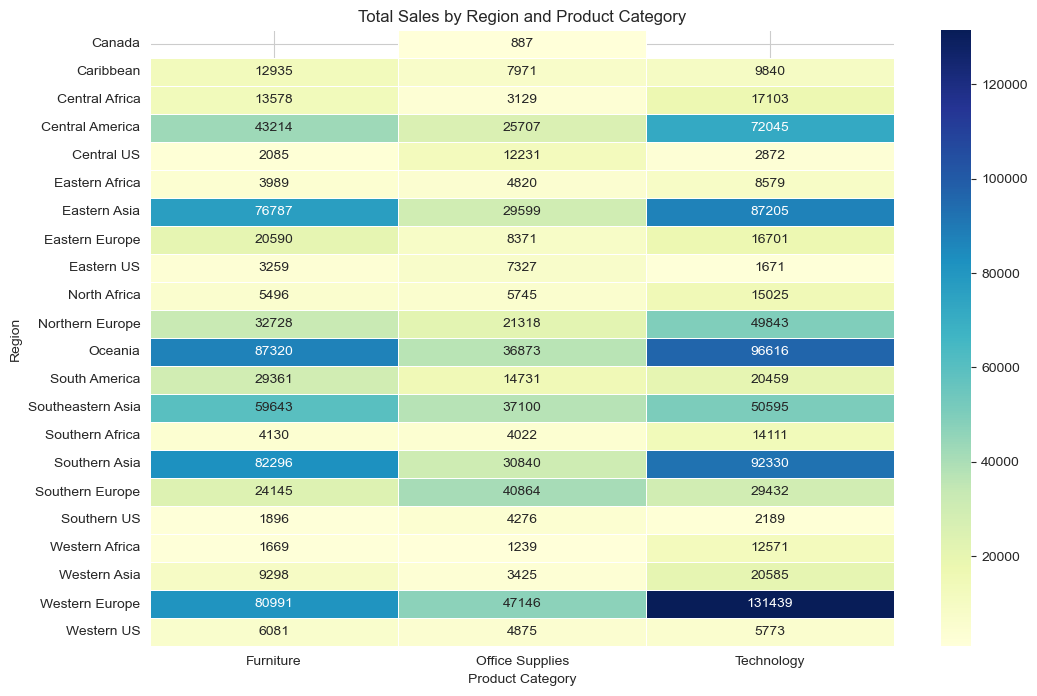

In [9]:
# Set a style for the plots for better aesthetics
sns.set_style("whitegrid")

# Create a bar chart of sales by product category
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=sales_by_category.index, y=sales_by_category.values, hue=sales_by_category.index, palette='viridis', legend=False)
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

# Plot a line graph of monthly sales over time
df['OrderYearMonth'] = df['Order Date'].dt.to_period('M')
monthly_sales = df.groupby('OrderYearMonth')['Sales'].sum()

# Convert Period to string for plotting if necessary, or just plot directly
monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(15, 7))
sns.lineplot(x=monthly_sales.index, y=monthly_sales.values, marker='o')
plt.title('Monthly Sales Over Time')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=90, ha='right', fontsize=8) # Rotate for readability, adjust font size
plt.grid(True)
plt.tight_layout()
plt.show()

# Generate a scatter plot of sales vs. profit
plt.figure(figsize=(10, 7))
sns.scatterplot(x='Sales', y='Profit', hue='Category', data=df, alpha=0.6)
plt.title('Sales vs. Profit by Product Category')
plt.xlabel('Sales ($)')
plt.ylabel('Profit ($)')
plt.grid(True)
plt.show()

# Produce a heatmap of sales by region and product category
sales_heatmap_data = df.pivot_table(index='Region', columns='Category', values='Sales', aggfunc='sum')

plt.figure(figsize=(12, 8))
sns.heatmap(sales_heatmap_data, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title('Total Sales by Region and Product Category')
plt.xlabel('Product Category')
plt.ylabel('Region')
plt.show()

Key Insights for GlobalMart

Based on the performed exploratory data analysis of the sales data, the following key insights can be derived:

1. Sales Dominance and Growth Over Time:

Product Categories: Office Supplies generate the highest sales volume, consistent with their high transaction frequency. However, Technology and Furniture demonstrate a higher average sales value per transaction, as indicated by their overall sales totals.

Temporal Trend: GlobalMart's sales exhibit a strong upward trend over the period 2012-2015, highlighting the company's growth. Monthly fluctuations decreased in 2015 compared to 2012, suggesting maturing and stabilising operations. A clear seasonality is also evident, with sales peaking towards the end of each year (November/December).

2. Profitability Challenges Despite Sales:

Although most transactions are profitable, the company incurs significant losses on some. The lowest profit values (down to approximately −3000) are primarily observed within the Office Supplies and Technology categories. This suggests that high sales do not always translate to profit, and certain products might be sold with excessive discounts or incur high operational costs.

Further Analysis Recommended: GlobalMart should investigate the root causes of these losses in specific categories, particularly concerning pricing strategies and discount policies.

3. Key Markets and Category Performance:

Regional Sales: Regions such as Asia Pacific, Western Europe, and Oceania are crucial markets, driving the highest sales across Furniture and Technology categories. Notably, Technology sales in Western Europe are exceptionally high.

Underperforming Areas/Weaknesses: Regions including Southern US, Western Africa, and Central US show very low sales in Furniture and Technology. Canada's sales performance is notably poor in Office Supplies and absent in Furniture and Technology, which could indicate untapped potential or challenges with market presence in that region.